# Daily statistics from hourly ERA5 data

In [1]:
# If first time running, uncomment the line below to install any additional dependancies
# !bash requirements-for-notebooks.sh

In [2]:
import earthkit.transforms as ek_aggregate
from earthkit import data as ek_data

from earthkit.data.testing import earthkit_remote_test_data_file

## Load some test data

All `earthkit-climate` methods can be called with `earthkit-data` objects (Readers and Wrappers) or with the 
pre-loaded `xarray`.

In this example we will use hourly ERA5 2m temperature data on a 0.5x0.5 spatial grid for the year 2015 as
our physical data; and we will use the NUTS geometries which are stored in a geojson file.

First we lazily load the ERA5 data  and NUTS geometries from our test-data repository.

Note the data is only downloaded when
we use it, e.g. at the `.to_xarray` line, additionally, the download is cached so the next time you run this
cell you will not need to re-download the file (unless it has been a very long time since you have run the
code, please see tutorials in `earthkit-data` for more details in cache management).

In [ ]:
# Get some demonstration ERA5 data, this could be any url or path to an ERA5 grib or netCDF file.
remote_era5_file = earthkit_remote_test_data_file("era5_temperature_europe_2015.grib")
era5_data = ek_data.from_source("url", remote_era5_file)
era5_xr = era5_data.to_xarray()

## Calculate the daily mean of the ERA5 data

In [4]:
era5_daily_mean = ek_aggregate.temporal.daily_mean(era5_data)
era5_daily_mean

<xarray.Dataset> Size: 165MB
Dimensions:                  (forecast_reference_time: 365, latitude: 201,
                              longitude: 281)
Coordinates:
  * latitude                 (latitude) float64 2kB 80.0 79.75 ... 30.25 30.0
  * longitude                (longitude) float64 2kB -10.0 -9.75 ... 59.75 60.0
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 3kB 201...
Data variables:
    2t                       (forecast_reference_time, latitude, longitude) float64 165MB ...
Attributes: (12/13)
    param:        2t
    paramId:      167
    class:        ea
    stream:       oper
    levtype:      sfc
    type:         an
    ...           ...
    date:         20150101
    time:         0
    domain:       g
    number:       0
    Conventions:  CF-1.8
    institution:  ECMWF

In [5]:
era5_t_red = ek_aggregate.temporal.reduce(era5_data)
era5_t_red

<xarray.Dataset> Size: 456kB
Dimensions:    (latitude: 201, longitude: 281)
Coordinates:
  * latitude   (latitude) float64 2kB 80.0 79.75 79.5 79.25 ... 30.5 30.25 30.0
  * longitude  (longitude) float64 2kB -10.0 -9.75 -9.5 ... 59.5 59.75 60.0
Data variables:
    2t         (latitude, longitude) float64 452kB 262.5 262.6 ... 297.4 294.4
Attributes: (12/13)
    param:        2t
    paramId:      167
    class:        ea
    stream:       oper
    levtype:      sfc
    type:         an
    ...           ...
    date:         20150101
    time:         0
    domain:       g
    number:       0
    Conventions:  CF-1.8
    institution:  ECMWF

## Calculate a rolling mean with a 50 timestep window

In [9]:
era5_rolling = ek_aggregate.rolling_reduce(
    era5_xr, forecast_reference_time=50, center=True,
)
era5_rolling

<xarray.Dataset> Size: 660MB
Dimensions:                  (forecast_reference_time: 1460, latitude: 201,
                              longitude: 281)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 12kB 20...
  * latitude                 (latitude) float64 2kB 80.0 79.75 ... 30.25 30.0
  * longitude                (longitude) float64 2kB -10.0 -9.75 ... 59.75 60.0
Data variables:
    2t                       (forecast_reference_time, latitude, longitude) float64 660MB dask.array<chunksize=(1459, 26, 36), meta=np.ndarray>
Attributes: (12/13)
    param:        2t
    paramId:      167
    class:        ea
    stream:       oper
    levtype:      sfc
    type:         an
    ...           ...
    date:         20150101
    time:         0
    domain:       g
    number:       0
    Conventions:  CF-1.8
    institution:  ECMWF

## Plot a random point location to see the different aggregation methods

Text(0.5, 1.0, 'Aggregation methods')

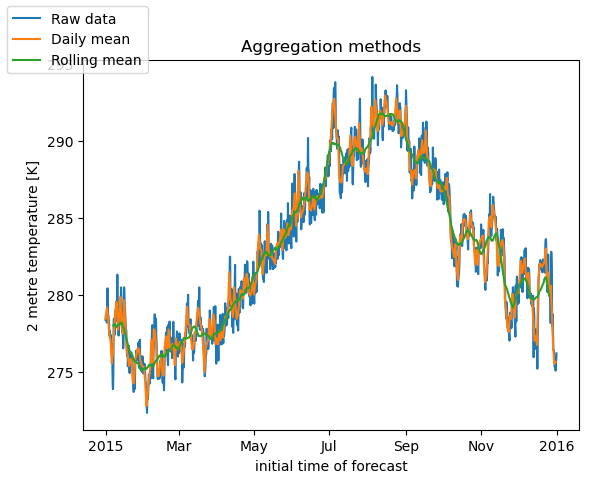

In [10]:
isel_kwargs = {"latitude":100, "longitude":100}
era5_data.to_xarray()['2t'].isel(**isel_kwargs).plot(label='Raw data')
era5_daily_mean['2t'].isel(**isel_kwargs).plot(label='Daily mean')
fig = era5_rolling['2t'].isel(**isel_kwargs).plot(label='Rolling mean')
figure = fig[0].get_figure()
figure.legend(loc=2)
figure.axes[0].set_title("Aggregation methods")

In [12]:
era5_rolling_multidim = ek_aggregate.temporal.rolling_reduce(
    era5_data, forecast_reference_time=30, lat=5, lon=5, center=True,
    how_dropna='all'
)
era5_rolling_multidim

<xarray.Dataset> Size: 647MB
Dimensions:                  (forecast_reference_time: 1431, latitude: 201,
                              longitude: 281)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 11kB 20...
  * latitude                 (latitude) float64 2kB 80.0 79.75 ... 30.25 30.0
  * longitude                (longitude) float64 2kB -10.0 -9.75 ... 59.75 60.0
Data variables:
    2t                       (forecast_reference_time, latitude, longitude) float64 647MB dask.array<chunksize=(730, 34, 47), meta=np.ndarray>
Attributes: (12/13)
    param:        2t
    paramId:      167
    class:        ea
    stream:       oper
    levtype:      sfc
    type:         an
    ...           ...
    date:         20150101
    time:         0
    domain:       g
    number:       0
    Conventions:  CF-1.8
    institution:  ECMWF

In [13]:
ek_aggregate.temporal.reduce(era5_data, how='quantile', q=[0.1, 0.9])

<xarray.Dataset> Size: 908kB
Dimensions:    (latitude: 201, longitude: 281, quantile: 2)
Coordinates:
  * latitude   (latitude) float64 2kB 80.0 79.75 79.5 79.25 ... 30.5 30.25 30.0
  * longitude  (longitude) float64 2kB -10.0 -9.75 -9.5 ... 59.5 59.75 60.0
  * quantile   (quantile) float64 16B 0.1 0.9
Data variables:
    2t         (quantile, latitude, longitude) float64 904kB 251.3 ... 306.9
Attributes: (12/13)
    param:        2t
    paramId:      167
    class:        ea
    stream:       oper
    levtype:      sfc
    type:         an
    ...           ...
    date:         20150101
    time:         0
    domain:       g
    number:       0
    Conventions:  CF-1.8
    institution:  ECMWF

In [14]:
rolling_kwargs =  {'forecast_reference_time': 50, 'center': True}
reduce_kwargs =  {}
data_rolling = era5_data.to_xarray().rolling(**rolling_kwargs)
data_rolling

DatasetRolling [forecast_reference_time->50(center)]

In [15]:
ek_aggregate.temporal.reduce(data_rolling)

Cannot find a wrapper for class: xarray.computation.rolling.DatasetRolling, returning unwrapped object
Cannot find a wrapper for class: xarray.computation.rolling.DatasetRolling, returning unwrapped object


<xarray.Dataset> Size: 660MB
Dimensions:                  (forecast_reference_time: 1460, latitude: 201,
                              longitude: 281)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 12kB 20...
  * latitude                 (latitude) float64 2kB 80.0 79.75 ... 30.25 30.0
  * longitude                (longitude) float64 2kB -10.0 -9.75 ... 59.75 60.0
Data variables:
    2t                       (forecast_reference_time, latitude, longitude) float64 660MB ...
Attributes: (12/13)
    param:        2t
    paramId:      167
    class:        ea
    stream:       oper
    levtype:      sfc
    type:         an
    ...           ...
    date:         20150101
    time:         0
    domain:       g
    number:       0
    Conventions:  CF-1.8
    institution:  ECMWF